# Implementation of MCP Neuron for AND and OR Function.

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  sum_array = []
  for i in range(len(X1)):
    sum_array.append(X1[i] + X2[i])
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  state_neuron = []
  for i in range(len(sum_array)):
    if sum_array[i] >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron

In [29]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [30]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    sum_array = []
    for i in range(len(X1)):
        sum_array.append(X1[i] + X2[i])
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron = []
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for i in range(len(sum_array)):
        if sum_array[i] >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron


In [31]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI Workshop/Week3/Data/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

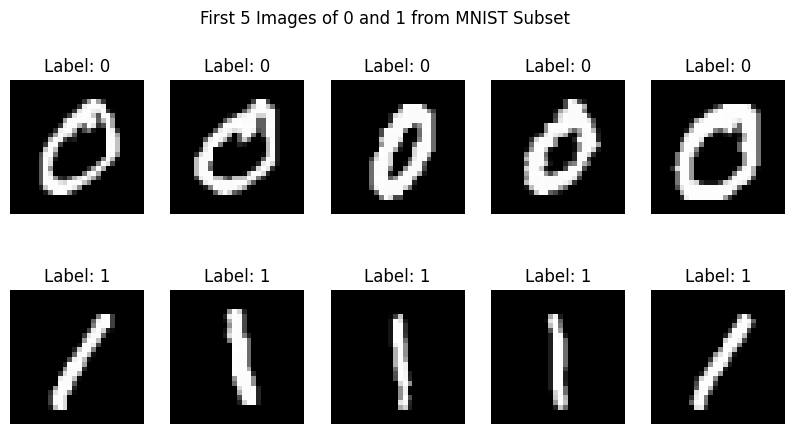

In [33]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [34]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [35]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [36]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        for i in range(len(X)):
            y_pred = decision_function(X[i], weights, bias)
            if y_pred != y[i]:
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate*(y[i]-y_pred)

        if(epoch+1)%10==0:
            y_pred_all = decision_function(X, weights, bias)
            accuracy = np.mean(y_pred_all == y)
            print(f"Epoch: {epoch+1} Accuracy: {accuracy}")
    return weights, bias, accuracy

## Training the Perceptron

In [37]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch: 10 Accuracy: 0.9992104224240032
Epoch: 20 Accuracy: 1.0
Epoch: 30 Accuracy: 1.0
Epoch: 40 Accuracy: 1.0
Epoch: 50 Accuracy: 1.0
Epoch: 60 Accuracy: 1.0
Epoch: 70 Accuracy: 1.0
Epoch: 80 Accuracy: 1.0
Epoch: 90 Accuracy: 1.0
Epoch: 100 Accuracy: 1.0
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [38]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# Implementation of MCP Neuron for AND and OR Function.

In [39]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  sum_array = []
  for i in range(len(X1)):
    sum_array.append(X1[i] + X2[i])
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  state_neuron = []
  for i in range(len(sum_array)):
    if sum_array[i] >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron

In [40]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [41]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    sum_array = []
    for i in range(len(X1)):
        sum_array.append(X1[i] + X2[i])
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron = []
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for i in range(len(sum_array)):
        if sum_array[i] >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron


In [42]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Limitation of MCP Neurons
1. It can only solve linearly separable problems
2. It has fixed weight which means it does not learn from the data and weight smust be manually assiigned
3. The inputs and outpus are of binary only.
4. It lacks several characteristics of biological networks.

# Q2. Implementation of MCP Neuron for AND and OR Function.
=> Yes we can develop a logic to solve XOR function using MCP Neuron with multiple MCP neurons. Yes we can devise a if else rules to make if both the input are same then 0 else 1.

#Part-2 (3 and 5)

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI Workshop/Week3/Data/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels
y = df_3_5["label"].values  # Labels (3 or 5)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


# Q1. What does the shape of X represent?
=> The shape of X represents the features coulumn of the dataset.Which means the faacotrs that are used in the prediction of target value. The shape (2741, 784) means , rows and column of the features in the dataset. As per output we have 2741 rows and 784 rows.

# Q2. What does the shape of Y represent?
=> The shape of Y represents the target coulumn of the dataset.Which means the value we want to predict. The shape is (2741,) which means, row is 2741 and in column there is no value which means it is only one column.

### Viewing the Dataset.

Error: Not enough images in images_3 or images_5 to plot 5 images.


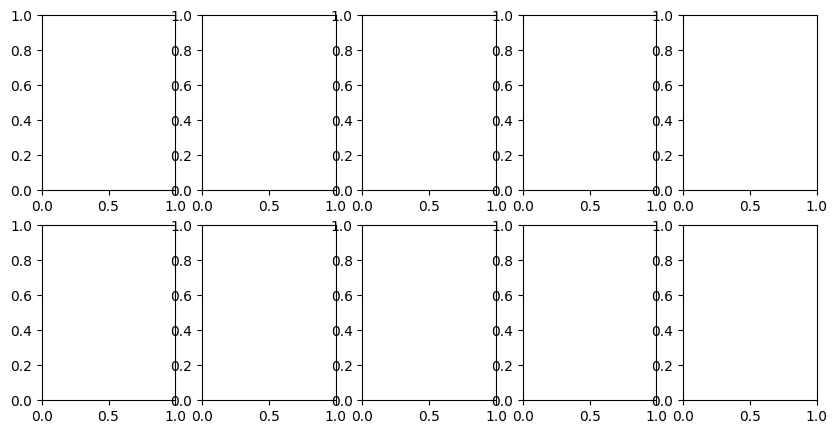

In [44]:
# Separate images for label 0 and label 1
images_3 = X[y == 3]  # Get all images with label 3 (chnaged)
images_5 = X[y == 5]  # Get all images with label 5 (changed)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [45]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Q1. What does the weights array represent in this context?
=> X.shape(1) will return the number of column of features (i.e. X), and it will create the 1D array with capacity of 784 form 0-783. Weights represents the how important is that data in the model training, in this case how important is the pixel. since there are 784 pixel the array can store the all the weights for each pixel.

# Q2. Why are we initializing the weights to zero? What effect could this have on the training process?
=> We initialize the weights to zero because we dont know how important is that pixel at the beginning.Initilizing it to zero will make it simple as when the model is training, gradient decent will update and change the weight differently as error is calculated.

## Step - 3 - Make a Decision function:

In [46]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 5, 3)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [47]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        for i in range(len(X)):
            y_pred = decision_function(X[i], weights, bias)
            if y_pred != y[i]:
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate*(y[i]-y_pred)

        if(epoch+1)%10==0:
            y_pred_all = decision_function(X, weights, bias)
            accuracy = np.mean(y_pred_all == y)
            print(f"Epoch: {epoch+1} Accuracy: {accuracy}")
    return weights, bias, accuracy

# Q1. What is the purpose of the output = np.dot(X[i], weights) + bias line?
=> The purpose of output = np.dot(X[i], weights) + bias ia to compute the weighted sum of inputs + bias value. In the formula, each pixel value is multiplied to its corresponding weight and all these product are summed together using dot product and bias is added to make a decision.


# Q2. What happens when the prediction is wrong? How are the weights and bias updated?
=> When the model makes a wrong prediction, which means the ouput does not match to the label then error is used to adjust the weight and bias so the prediction improves. The model calcullates how far is the error by compareing the output value and the actual value  and then update the weights accordlinly. The bias is also updated similarly.

# Q3. Why is the final accuracy important, and what do you expect it to be?
=> Final accuracy is important because it measure how well the trained model performed by calculating the average of the correct prediction by comparing the predicited label with actual label.This represents the how is the model performace and reflects how well weights and bias are trained.


## Training the Perceptron

In [48]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print(f"The Final Accuracy is: {accuracy:.4f}")

Epoch: 10 Accuracy: 0.0
Epoch: 20 Accuracy: 0.0
Epoch: 30 Accuracy: 0.0
Epoch: 40 Accuracy: 0.0
Epoch: 50 Accuracy: 0.0
Epoch: 60 Accuracy: 0.0
Epoch: 70 Accuracy: 0.0
Epoch: 80 Accuracy: 0.0
Epoch: 90 Accuracy: 0.0
Epoch: 100 Accuracy: 0.0
The Final Accuracy is: 0.0000


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.0000


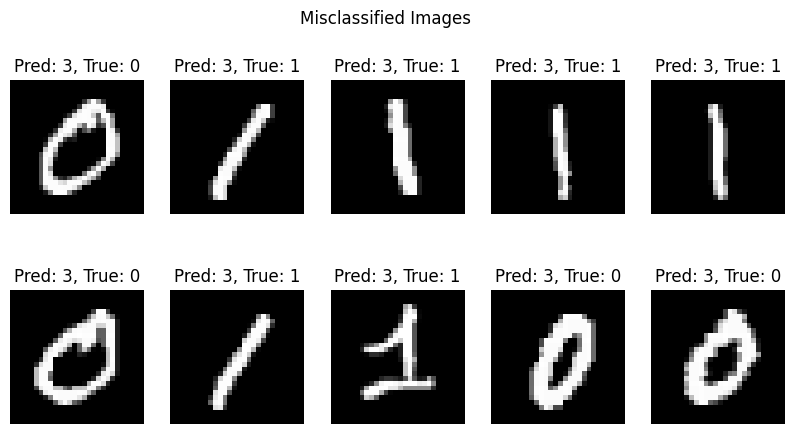

In [49]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

#Q1. What does misclassified idx store, and how is it used in this code?
=> misclassified_idx stores the indices of all data point where model label prediction do not match the actual label (y_pred != y). In the code np.where() is used and actual and predicted label is compared if does not match which is error then of that image row indices is stored in the array. as np.where returns tupes with array inside we use [0] at last to extract the arrary only and through accessing each array element which is the image indices it is displayed as image.

#Q2.How do you interpret the result if the output is ”All images were correctly classified!”?How do you interpret the result if the output is ”All images were correctly classified!”?
=> As seen in the figure of Misclassified Images (whose actual and predicted label does not match) as 10 images whose pridiction were wrong is shown. As the accuracy was 0.9869 for this model there was expectation of wrong prediction.
Also if we see the for the figures of number 5 whose prediction was wrong there is similarity in the bottom left side the ending of 5 is stretched long so it predicts as 3 rather than 5. And for the 3's if the upper curve is smaller than lower curve it then predict as 5. Also there are some data which is not clear even from the human perspective those data must be removed as it decreses the model capacity.